In [1]:
from src.dataset.dice_score.dataset import ( S7DatasetDiceScore,)
from src.dataset.dice_score.data import get_dice_crops

from src.parse.config import load_config

from src.task.dice_score.inference import DiceScoreInference

2026-03-19 15:00:36.605029: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-19 15:00:36.617153: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-19 15:00:36.631177: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-19 15:00:36.635293: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-19 15:00:36.646502: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Load configuration
config = load_config("config/config.yml")
print(f"Dataset path: {config.dataset_path}")

Dataset path: ../datasets/s7dataset-2-dice-detection


## Test Dice Score Classification Model

In [3]:
# Load dice crops for score classification
dice_crops = get_dice_crops(dataset_path=config.dataset_path, num_workers=4)
print(f"Loaded {len(dice_crops)} dice crops")

# Load dataset
dataset = S7DatasetDiceScore(
    dice_crops=dice_crops,
    image_resolution=config.tasks.dice_score.image_resolution,
    colored=config.colored
)

Loaded 1000 dice crops


In [4]:
def generate_dice_score():
    for img, lbl in dataset:
        yield img, lbl
        
dice_score_generator = generate_dice_score()

In [5]:
dice_score_inference = DiceScoreInference(
    model_path=config.tasks.dice_score.inference_path,
    image_resolution=config.tasks.dice_score.image_resolution,
    colored=config.colored
)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


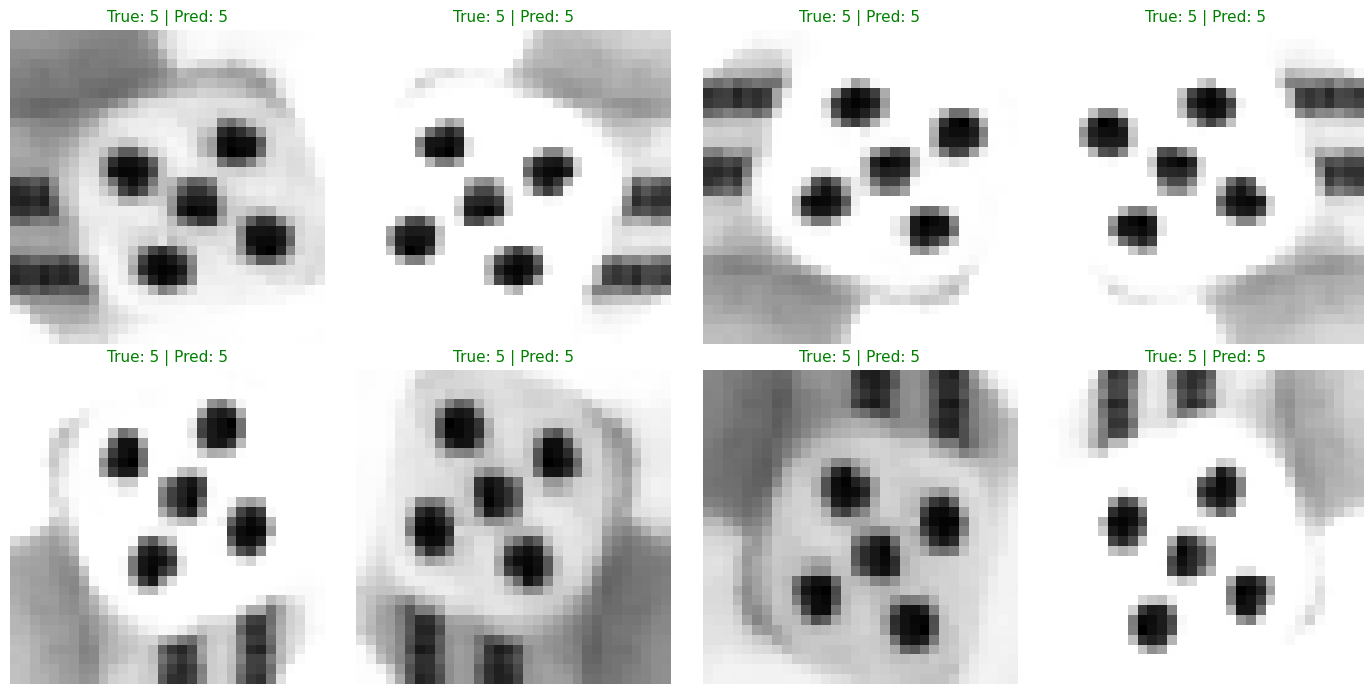

Green = Correct prediction, Red = Incorrect prediction


In [13]:
import matplotlib.pyplot as plt

# Visualize score classification predictions
num_viz_images = 8

# Create figure
rows = 2
cols = 4
fig, axes = plt.subplots(rows, cols, figsize=(14, 7))
axes = axes.flatten()

for i in range(num_viz_images):
    ax = axes[i]

    # Get next image and label from generator
    img, lbl = next(dice_score_generator)
    ax.imshow(img.squeeze(), cmap='gray')

    true_score = lbl + 1  # Convert 0-5 to 1-6
    pred_score = dice_score_inference(img)
    
    # Green if correct, red if incorrect
    color = 'green' if true_score == pred_score else 'red'
    ax.set_title(f"True: {true_score} | Pred: {pred_score}", color=color, fontsize=11)
    ax.axis('off')

# Hide unused subplots if any
for i in range(num_viz_images, rows * cols):
    axes[i].axis('off')

plt.tight_layout()
plt.show()
print("Green = Correct prediction, Red = Incorrect prediction")